**Lab 6**

Implement the non-parametric Locally Weighted Regression algorithm in order to fit data points. Select appropriate data set for your experiment and draw graphs.

In [ ]:
# Import required packages
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define Gaussian Kernel algorithm
def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau**2))

In [ ]:
# Define Locally Weighted Regression algorithm
def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    X_transpose_W = X.T @ W
    theta = np.linalg.inv(X_transpose_W @ X) @ X_transpose_W @ y
    return x @ theta

In [ ]:
# Implement Locally Weighted Regression to fit data points
np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)
X_bias = np.c_[np.ones(X.shape), X]

x_test = np.linspace(0, 2 * np.pi, 200)
x_test_bias = np.c_[np.ones(x_test.shape), x_test]
tau = 0.5
y_pred = np.array(
    [locally_weighted_regression(xi, X_bias, y, tau) for xi in x_test_bias]
)

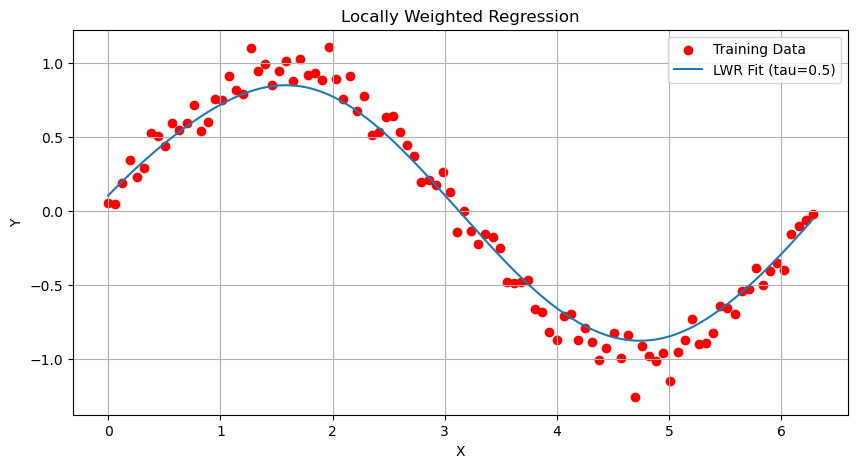

In [ ]:
# Plot the graphs
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="red", label="Training Data")
plt.plot(x_test, y_pred, label=f"LWR Fit (tau={tau})")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Locally Weighted Regression")
plt.legend()
plt.grid()
plt.show()